## Setting

In [51]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Importing Dependencies

In [2]:
!pip install nltk
!pip install -U pandas-profiling
!pip install pydantic==1.10.10

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 357.5/357.5 kB 24.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.8/395.8 kB 29.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 10.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.5/679.5 kB 39.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 26.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 63.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 76.1 MB/s eta 0:00:00
  Created wheel for htmlmin: filename=htmlmin-0.1.12-py3-none-any.whl size=27081 sha256=20f070b5c094ae4511bd9bd96bfbce26ac3b49d2267d659e6fa40b70fe89d84d
  Stored in directory: /root/.cache/pip/wheels/dd/91/29/a79cecb328d01739e64017b6fb9a1ab9d8cb1853098ec5966d
Successfully built htmlmin
  Attempting unin

In [3]:
import string
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
# import ydata_profiling

import numpy as np

import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer, PorterStemmer


from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, TfidfTransformer
from sklearn.preprocessing import MinMaxScaler, MaxAbsScaler, RobustScaler, Normalizer, normalize

from sklearn.mixture import GaussianMixture

from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

from sklearn.decomposition import PCA, LatentDirichletAllocation
from sklearn.cluster import SpectralClustering

from wordcloud import WordCloud

%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

from matplotlib.ticker import MaxNLocator

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

stemmer = PorterStemmer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


### Data Load & EDA

In [4]:
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/pilot_data.csv", encoding = 'cp949')
# data.profile_report()

## STEP 1 : Data Claeaning

In [5]:
# delected data where the abstract or title information was missing or was a duplicate
data.dropna(subset=['Abstract'], inplace=True)

data.drop_duplicates(subset=['Article Title'], inplace=True)
data.drop_duplicates(subset=['Abstract'], inplace=True)

print("총 Document 수 :", data.shape[0])

총 Document 수 : 995


In [6]:
# make corpus
def combine_3rd_columns(col_1, col_2, col_3):

    result = col_1

    if not pd.isna(col_2):
        result += " " + str(col_2)

    if not pd.isna(col_3):
        result += " " + str(col_3)

    return result

data["text"] = data.apply(lambda x: combine_3rd_columns(x['Article Title'], x['Abstract'], x['Author Keywords']), axis=1)

df = data.loc[:, ['text', 'Article Title']]
df.head()

,text,Article Title
0,A Framework of Smart-Home Service for Elderly'...,A Framework of Smart-Home Service for Elderly'...
1,Service Provisioning Framework for Digital Sma...,Service Provisioning Framework for Digital Sma...
2,Analysis of Types and Importance of Sensors in...,Analysis of Types and Importance of Sensors in...
3,Smart Home Services Based on Event Matching Th...,Smart Home Services Based on Event Matching
4,A Proposal for an Integrated Smart Home Servic...,A Proposal for an Integrated Smart Home Servic...


#### Data preprocessing

In [7]:
def preprocess_text(text):

    # Tokenize the text (split it into individual words)
    words = nltk.word_tokenize(text)

    # Initialize lists to hold the original and lemmatized words
    original_words = []
    lemmatized_words = []

    words = [token for token in words if token not in string.punctuation]

    for word in words:
        word = word.lower()

        if word not in stop_words and not word.isdigit() :
            lemma = lemmatizer.lemmatize(word)
            lemmatized_words.append(lemma)

            if word != lemma :
                original_words.append({word : lemma})

    # Remove numbers and rejoin the tokens into a string
    processed_text = ' '.join([token for token in lemmatized_words])

    return processed_text, original_words

# Apply the function to the 'text' column of df
df['processed_data'] = df['text'].apply(preprocess_text)

# Split the processed_data column into two separate columns: one for processed text and one for lemma pairs.
df[['corpus', 'lemma_pairs']] = pd.DataFrame(df['processed_data'].tolist(), index=df.index)

# Drop the now redundant 'processed_data' column.
df.drop(columns=['processed_data'], inplace=True)

df.head()

,text,Article Title,corpus,lemma_pairs
0,A Framework of Smart-Home Service for Elderly'...,A Framework of Smart-Home Service for Elderly'...,framework smart-home service elderly 's biophi...,"[{'services': 'service'}, {'supports': 'suppor..."
1,Service Provisioning Framework for Digital Sma...,Service Provisioning Framework for Digital Sma...,service provisioning framework digital smart h...,"[{'services': 'service'}, {'services': 'servic..."
2,Analysis of Types and Importance of Sensors in...,Analysis of Types and Importance of Sensors in...,analysis type importance sensor smart home ser...,"[{'types': 'type'}, {'sensors': 'sensor'}, {'s..."
3,Smart Home Services Based on Event Matching Th...,Smart Home Services Based on Event Matching,smart home service based event matching smart ...,"[{'services': 'service'}, {'technologies': 'te..."
4,A Proposal for an Integrated Smart Home Servic...,A Proposal for an Integrated Smart Home Servic...,proposal integrated smart home service platfor...,"[{'devices': 'device'}, {'consumers': 'consume..."


##### Customized rules : do not lemmatize “glasses” to “glass”



In [8]:
check_list = df.loc[:, ['lemma_pairs']]
df = df.loc[:, ['corpus', 'Article Title']]

combined_list = check_list['lemma_pairs'].sum()

def remove_duplicates(lst):
    result = []
    for item in lst:
        if item not in result:
            result.append(item)
    return result

unique_ordered_list  = remove_duplicates(combined_list)

keys, values = [], []

for d in unique_ordered_list:
    for key, value in d.items():
        keys.append(key)
        values.append(value)

checks = pd.DataFrame({'Key': keys, 'Value': values})
checks.drop_duplicates(subset=['Key'], inplace=True)
checks.drop_duplicates(subset=['Value'], inplace=True)

def check_meaning(word):
    singular = wordnet.synsets(word)
    plural = wordnet.synsets(word + 's')

    if singular and plural:
        if singular[0].definition() != plural[0].definition():
            return (True, f"'{word}': {singular[0].definition()}", f"'{word}s': {plural[0].definition()}")

    return (False, None, None)

checks['is_different'], checks['singular_def'], checks['plural_def'] = zip(*checks['Value'].map(check_meaning))

checks[checks['is_different']].to_csv('/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/customized(not_lemmatize).csv', index=False)

In [9]:
df = df.loc[:, ['corpus', 'Article Title']]
df.dropna(subset=['corpus'], inplace=True)

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df['corpus'])

print("현재 Document 갯수:",tfidf_matrix.shape[0])
print("현재 word-feature 갯수:",tfidf_matrix.shape[1])

현재 Document 갯수: 995
현재 word-feature 갯수: 7654


###  Word-feature - finding core vector space

#### word_featuring_1) Deciding on the number of keywords to be selected from each item

In [10]:
# visualization function
from matplotlib.ticker import FuncFormatter

def plot_keywords(x, y, y_label, title):
    plt.figure(figsize=(10,6))

    plt.plot(x, y,  marker='o', color = 'b')

    plt.gca().invert_xaxis()

    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['left'].set_visible(False)
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

    plt.xticks(range(min(keyword_counts), max(keyword_counts)+1))

    # K formatter
    k_formatter = FuncFormatter(lambda x, pos: f'K{x}')

    # Apply the formatter
    plt.gca().xaxis.set_major_formatter(k_formatter)

    plt.xlabel('Number of selected top keywords from each data')
    plt.ylabel(y_label)

    for i in [4, 5]:
        if i in x:
            index = x.index(i)
            plt.plot(i, y[index], marker='o', color='r')

    plt.title(title)
    plt.show()

##### Metric 1 : Mean of the TF-IDF scores of a word-feature across data

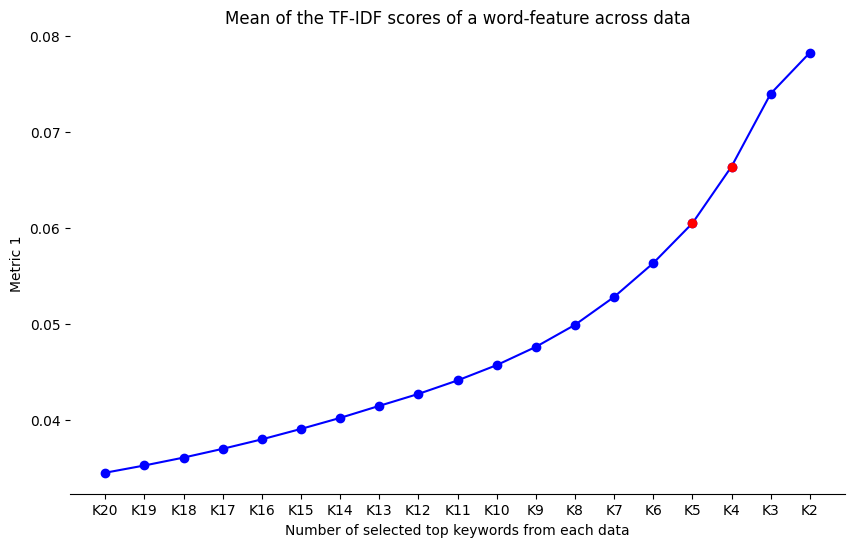

In [11]:
mean_tfidf_scores = []
keyword_counts = list(range(20, 1, -1))  # 20개부터 2개까지

for count in keyword_counts:
    top_keywords_indices = np.argsort(np.asarray(tfidf_matrix.mean(axis=0)).ravel())[::-1][:count]
    mean_score = tfidf_matrix[:, top_keywords_indices].mean()
    mean_tfidf_scores.append(mean_score)

plot_keywords(keyword_counts, mean_tfidf_scores, 'Metric 1',  'Mean of the TF-IDF scores of a word-feature across data')

##### Metric 2 : Mean of the cosine similarities of a word-feature to other features

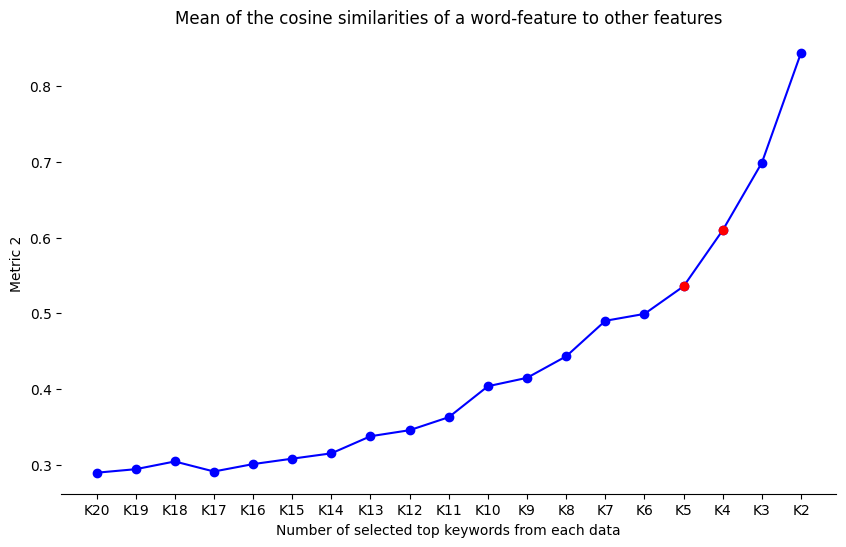

In [12]:
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df['corpus'])
tfidf_matrix_transposed = tfidf_matrix.T

mean_cosine_similarities = []
keyword_counts = list(range(20, 1, -1))  # 20개부터 2개까지

for count in keyword_counts:
    top_keywords_indices = np.argsort(np.asarray(tfidf_matrix_transposed.mean(axis=1)).ravel())[::-1][:count]
    similarity_matrix = cosine_similarity(tfidf_matrix_transposed[top_keywords_indices])
    mean_similarity = np.mean(similarity_matrix[np.triu_indices(count, k=1)])
    mean_cosine_similarities.append(mean_similarity)

plot_keywords(keyword_counts, mean_cosine_similarities,'Metric 2', 'Mean of the cosine similarities of a word-feature to other features')

##### Metric 3 : Cosine similarity between a word-feature and the centroid of features

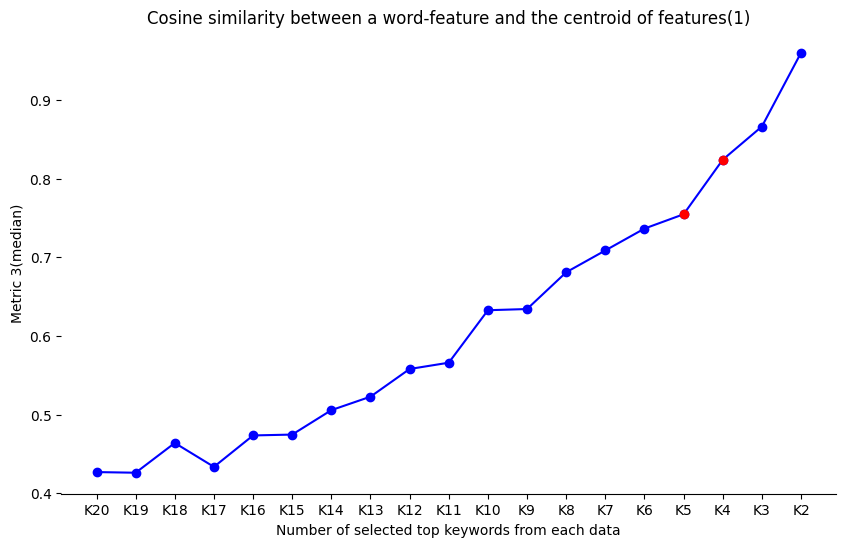

In [13]:
# meadian 사용
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df['corpus'])
tfidf_matrix_transposed = tfidf_matrix.toarray().T

mean_cosine_similarities = []
keyword_counts = list(range(20, 1, -1))  # 20개부터 2개까지

for count in keyword_counts:
    top_keywords_indices = np.argsort(np.asarray(tfidf_matrix_transposed.mean(axis=1)).ravel())[::-1][:count]
    centroid_vector = np.median(tfidf_matrix_transposed[top_keywords_indices], axis=0).reshape(1, -1)
    similarity_to_centroid = cosine_similarity(tfidf_matrix_transposed[top_keywords_indices], centroid_vector)
    mean_similarity_to_centroid = similarity_to_centroid.mean()
    mean_cosine_similarities.append(mean_similarity_to_centroid)

plot_keywords(keyword_counts, mean_cosine_similarities, "Metric 3(median)", "Cosine similarity between a word-feature and the centroid of features(1)")

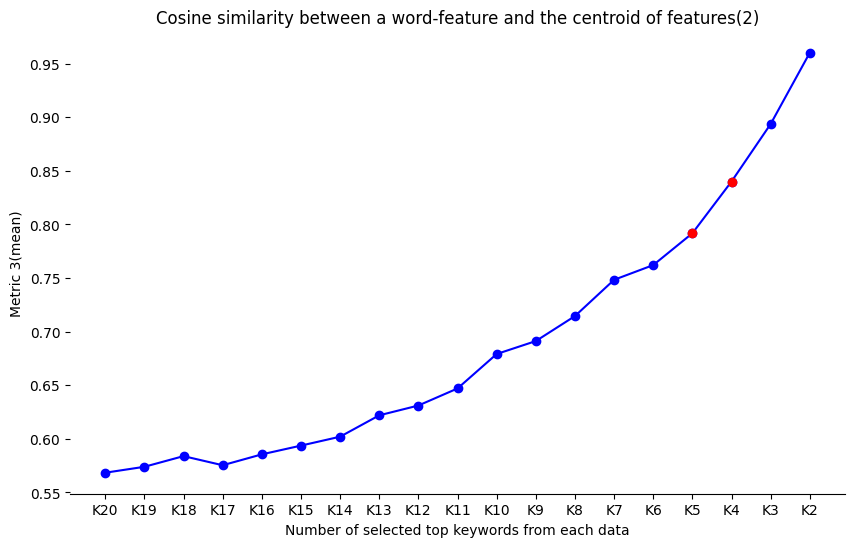

In [14]:
# 평균 사용
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df['corpus'])
tfidf_matrix_transposed = tfidf_matrix.toarray().T

mean_cosine_similarities = []
keyword_counts = list(range(20, 1, -1))  # 20개부터 2개까지

for count in keyword_counts:
    top_keywords_indices = np.argsort(np.asarray(tfidf_matrix_transposed.mean(axis=1)).ravel())[::-1][:count]
    centroid_vector = np.asarray(tfidf_matrix_transposed[top_keywords_indices].mean(axis=0)).reshape(1, -1)
    similarity_to_centroid = cosine_similarity(tfidf_matrix_transposed[top_keywords_indices], centroid_vector)
    mean_similarity_to_centroid = similarity_to_centroid.mean()
    mean_cosine_similarities.append(mean_similarity_to_centroid)

plot_keywords(keyword_counts, mean_cosine_similarities, "Metric 3(mean)", "Cosine similarity between a word-feature and the centroid of features(2)")

##### Metric 4 : Mean of the dot product scores of a word-feature to other features

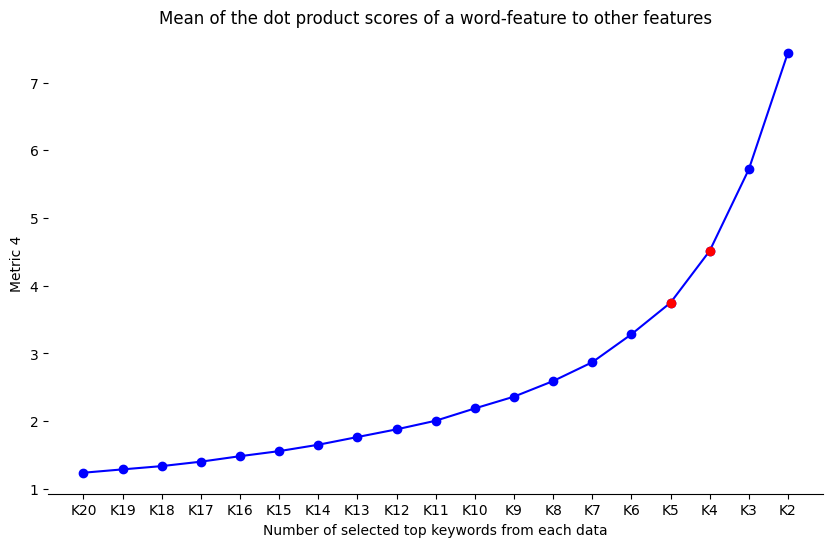

In [15]:
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df['corpus'])
tfidf_matrix_transposed = tfidf_matrix.T

mean_dot_product_scores = []
keyword_counts = list(range(20, 1, -1))

for count in keyword_counts:
    top_keywords_indices = np.argsort(np.asarray(tfidf_matrix_transposed.mean(axis=1)).ravel())[::-1][:count]
    dot_product_matrix = np.dot(tfidf_matrix_transposed[top_keywords_indices], tfidf_matrix_transposed[top_keywords_indices].T)
    mean_dot_product_score = np.mean(dot_product_matrix[np.triu_indices(count, k=1)])
    mean_dot_product_scores.append(mean_dot_product_score)

plot_keywords(keyword_counts, mean_dot_product_scores,"Metric 4", "Mean of the dot product scores of a word-feature to other features")

##### Metric 5 : LDA score of a word-feature for the single topic of entire data set

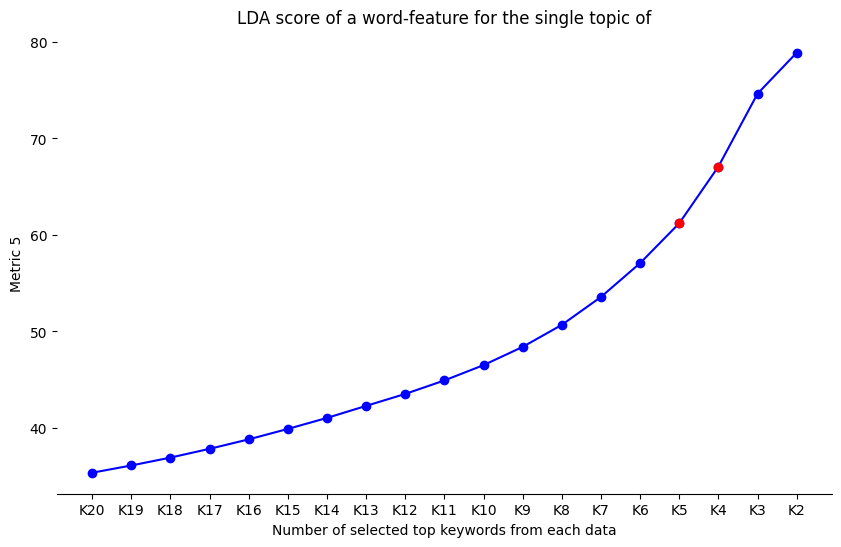

In [16]:
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df['corpus'])

lda_model = LatentDirichletAllocation(n_components=1, random_state=42)
lda_model.fit(tfidf_matrix)

mean_lda_scores = []
keyword_counts = list(range(20, 1, -1))  # 20개부터 2개까지

for count in keyword_counts:
    top_keywords_indices = lda_model.components_.argsort()[0, -count:]
    mean_lda_score = lda_model.components_[0, top_keywords_indices].mean()
    mean_lda_scores.append(mean_lda_score)

plot_keywords(keyword_counts, mean_lda_scores,"Metric 5", "LDA score of a word-feature for the single topic of")

##### Result

In [17]:
# Items 당 상위 4개의 단어 선택 - Type 3 제거
top_keywords_per_document = []
feature_names = tfidf_vectorizer.get_feature_names_out()

for i in range(len(df)):
    tfidf_scores = zip(feature_names, tfidf_matrix[i].toarray()[0])
    sorted_tfidf_scores = sorted(tfidf_scores,key=lambda x: x[1], reverse=True)

    top_keywords_per_document.append([keyword for keyword,_ in sorted_tfidf_scores[:5]])

# 전체 데이터셋에서 적어도 2번 이상 나온 키워드 추출하기 - Type 1 제거
all_keywords=[keyword for document in top_keywords_per_document for keyword in document]
selected_keywords=list(set(keyword for keyword in all_keywords if all_keywords.count(keyword) >=2))

vectorizer = TfidfVectorizer(vocabulary=selected_keywords)
tfidf_matrix = vectorizer.fit_transform(df['corpus'])

print("현재 Document 갯수:",tfidf_matrix.shape[0])
print("현재 word-feature 갯수:",tfidf_matrix.shape[1])

현재 Document 갯수: 995
현재 word-feature 갯수: 696


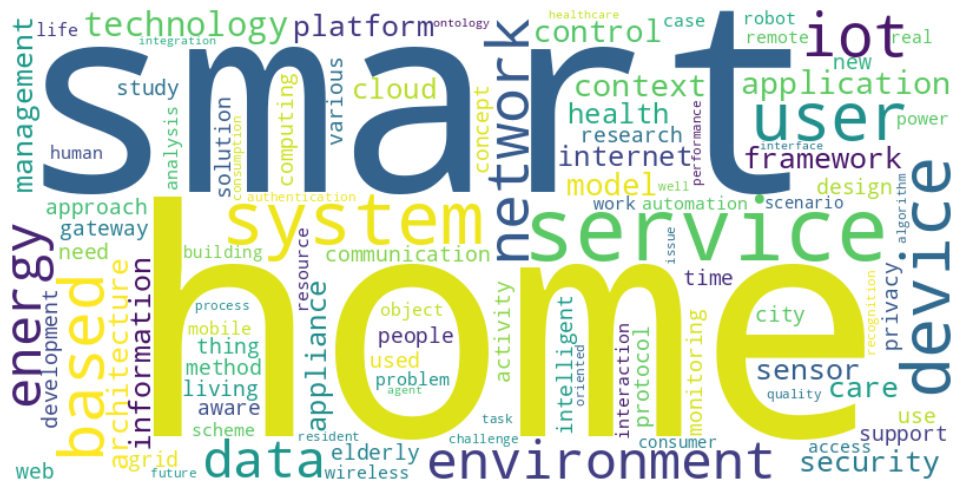

In [18]:
vectorizer = TfidfVectorizer(vocabulary=selected_keywords)
X = vectorizer.fit_transform(df['corpus'])

tfidf_sum = np.sum(X.toarray(), axis=0)


word_tfidf_dict = dict(zip(vectorizer.get_feature_names_out(), tfidf_sum))
top_100_words = sorted(word_tfidf_dict.items(), key=lambda x: x[1], reverse=True)[:100]
top_100_wordcloud_dict = dict(top_100_words)

wordcloud = WordCloud(width=800,
                      height=400,
                      background_color = 'white',).generate_from_frequencies(top_100_wordcloud_dict)

# 결과 출력
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.tight_layout(pad=0)
plt.axis('off')
plt.show()

#### word_featuring_2) Clustering based on Gaussian mixture model (GMM)

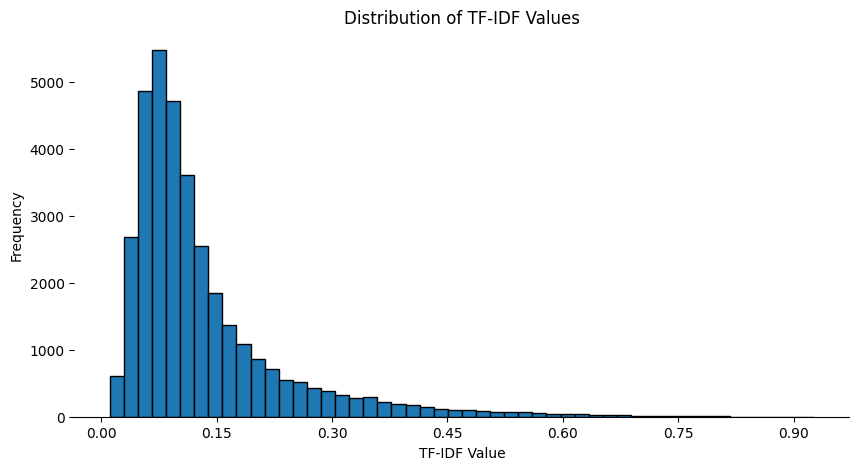

In [19]:
# Checked distribution of words : TF-IDF
tfidf_values = X.data

plt.figure(figsize=(10, 5))
plt.hist(tfidf_values, bins=50, edgecolor='black')

plt.xlabel('TF-IDF Value')
plt.ylabel('Frequency')
plt.title('Distribution of TF-IDF Values')


plt.gca().spines['right'].set_visible(False)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))

plt.show()

In [20]:
vectorizer = TfidfVectorizer(vocabulary=selected_keywords)
X = vectorizer.fit_transform(df['corpus'])
feature_names = vectorizer.get_feature_names_out()
tfidf_matrix_transposed = X.T.toarray()

In [28]:
vectorizer = TfidfVectorizer(vocabulary=selected_keywords)
feature_names = vectorizer.get_feature_names_out()

tfidf_matrix = vectorizer.fit_transform(df['corpus'])
tfidf_matrix_transposed = tfidf_matrix.T.toarray()

two_keywords_set = None

for i in range(10):

    gmm = GaussianMixture(n_components=100)
    gmm.fit(tfidf_matrix_transposed)

    cluster_labels = gmm.predict(tfidf_matrix_transposed)

    df_clustered_keywords = pd.DataFrame(feature_names, columns=['keyword'])
    df_clustered_keywords['cluster'] = cluster_labels

    max_data_pointer_cluster_label = df_clustered_keywords['cluster'].value_counts().idxmax()
    max_data_pointer_cluster = df_clustered_keywords[df_clustered_keywords['cluster'] == max_data_pointer_cluster_label]['keyword'].values.tolist()
    print(f"{i + 1}번째 시행 클러스터 속 데이터 갯수:", len(max_data_pointer_cluster))

    if two_keywords_set is None:
        two_keywords_set=set(max_data_pointer_cluster)

    else:
        two_keywords_set=two_keywords_set.union(set(max_data_pointer_cluster))

extract_keywords_list = list(two_keywords_set)
select_keywords_list = [keyword for keyword in selected_keywords if keyword not in extract_keywords_list]

print(" ")
print("합집합")

print("Type2로 선정되 단어 갯수", len(select_keywords_list))
print("Type1&Type3로 추출된 단어 갯수 :", len(extract_keywords_list))

1번째 시행 클러스터 속 데이터 갯수: 579
2번째 시행 클러스터 속 데이터 갯수: 495
3번째 시행 클러스터 속 데이터 갯수: 527
4번째 시행 클러스터 속 데이터 갯수: 436
5번째 시행 클러스터 속 데이터 갯수: 532
6번째 시행 클러스터 속 데이터 갯수: 536
7번째 시행 클러스터 속 데이터 갯수: 537
8번째 시행 클러스터 속 데이터 갯수: 546
9번째 시행 클러스터 속 데이터 갯수: 526
10번째 시행 클러스터 속 데이터 갯수: 423
 
합집합
Type2로 선정되 단어 갯수 69
Type1&Type3로 추출된 단어 갯수 : 627


In [29]:
vectorizer = TfidfVectorizer(vocabulary=selected_keywords)
feature_names = vectorizer.get_feature_names_out()

tfidf_matrix = vectorizer.fit_transform(df['corpus'])
tfidf_matrix_transposed = tfidf_matrix.T.toarray()

two_keywords_set = None

for i in range(10):

    gmm = GaussianMixture(n_components=100)
    gmm.fit(tfidf_matrix_transposed)

    cluster_labels = gmm.predict(tfidf_matrix_transposed)

    df_clustered_keywords = pd.DataFrame(feature_names, columns=['keyword'])
    df_clustered_keywords['cluster'] = cluster_labels

    max_data_pointer_cluster_label = df_clustered_keywords['cluster'].value_counts().idxmax()
    max_data_pointer_cluster = df_clustered_keywords[df_clustered_keywords['cluster'] == max_data_pointer_cluster_label]['keyword'].values.tolist()
    print(f"{i + 1}번째 시행 클러스터 속 데이터 갯수:", len(max_data_pointer_cluster))

    if two_keywords_set is None:
        two_keywords_set=set(max_data_pointer_cluster)

    else:
        two_keywords_set=two_keywords_set.intersection(set(max_data_pointer_cluster))

extract_keywords_list = list(two_keywords_set)
select_keywords_list = [keyword for keyword in selected_keywords if keyword not in extract_keywords_list]

print(" ")
print("교집합")
print("Type2로 선정되 단어 갯수", len(select_keywords_list))
print("Type1&Type3로 추출된 단어 갯수 :", len(extract_keywords_list))

1번째 시행 클러스터 속 데이터 갯수: 573
2번째 시행 클러스터 속 데이터 갯수: 530
3번째 시행 클러스터 속 데이터 갯수: 463
4번째 시행 클러스터 속 데이터 갯수: 516
5번째 시행 클러스터 속 데이터 갯수: 532
6번째 시행 클러스터 속 데이터 갯수: 520
7번째 시행 클러스터 속 데이터 갯수: 552
8번째 시행 클러스터 속 데이터 갯수: 560
9번째 시행 클러스터 속 데이터 갯수: 443
10번째 시행 클러스터 속 데이터 갯수: 562
 
교집합
Type2로 선정되 단어 갯수 414
Type1&Type3로 추출된 단어 갯수 : 282


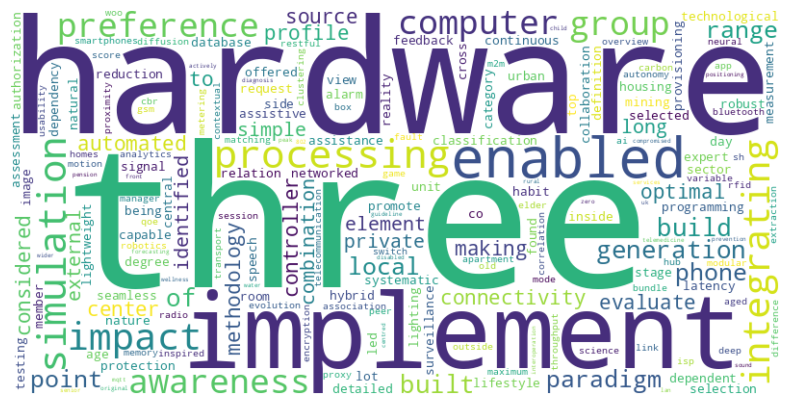

In [30]:
vectorizer = TfidfVectorizer(vocabulary=extract_keywords_list)
tfidf_matrix = vectorizer.fit_transform(df['corpus'])
avg_tfidf_values = tfidf_matrix.mean(axis=0).A1
keyword_tfidf_dict = dict(zip(vectorizer.get_feature_names_out(), avg_tfidf_values))

for word, value in keyword_tfidf_dict.items():
    if np.isnan(value):
        print(f"'{word}' has a TF-IDF value of NaN.")
        keyword_tfidf_dict[word] = 0

wordcloud = WordCloud(width=800, height=400, background_color='white')
wordcloud.generate_from_frequencies(frequencies=keyword_tfidf_dict)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

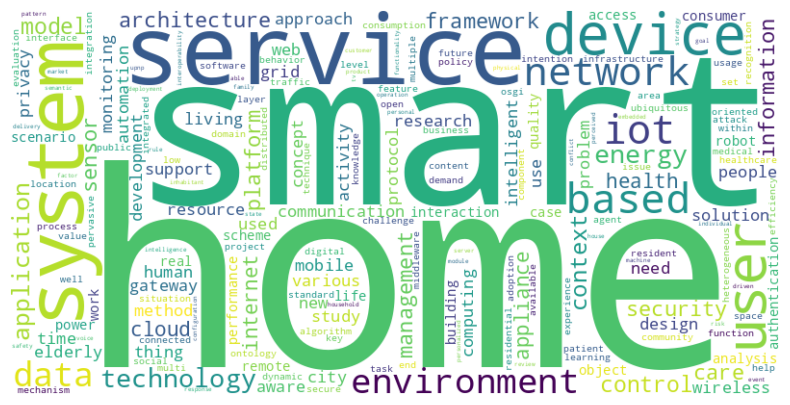

In [31]:
vectorizer = TfidfVectorizer(vocabulary=select_keywords_list)
tfidf_matrix = vectorizer.fit_transform(df['corpus'])
avg_tfidf_values = tfidf_matrix.mean(axis=0).A1
keyword_tfidf_dict = dict(zip(vectorizer.get_feature_names_out(), avg_tfidf_values))

for word, value in keyword_tfidf_dict.items():
    if np.isnan(value):
        print(f"'{word}' has a TF-IDF value of NaN.")
        keyword_tfidf_dict[word] = 0


wordcloud = WordCloud(width=800, height=400, background_color='white')
wordcloud.generate_from_frequencies(frequencies=keyword_tfidf_dict)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [38]:
print("현재 Document 갯수:",tfidf_matrix.shape[0])
print("현재 word-feature 갯수:",tfidf_matrix.shape[1])

현재 Document 갯수: 995
현재 word-feature 갯수: 414


In [39]:
checking_1= pd.DataFrame(select_keywords_list, columns = ['keyword'])
checking_1.to_csv('/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/final_select_keyword.csv', index=False)

checking_2 = pd.DataFrame(extract_keywords_list, columns = ['keyword'])
checking_2.to_csv('/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/stopwords.csv', index=False)

### Eliminated outliers by calculating the cosine similarities(Entire dataset)

In [40]:
vectorizer = TfidfVectorizer(vocabulary=select_keywords_list)
tfidf_matrix = vectorizer.fit_transform(df['corpus'])

tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=vectorizer.get_feature_names_out(), index=df.index)

cosine_sim = cosine_similarity(tfidf_df) - np.eye(tfidf_df.shape[0])

mean_cosine_sim = np.mean(cosine_sim, axis=1)

df_cosine_sim = pd.DataFrame(mean_cosine_sim, columns=['Mean Cosine Similarity'], index=df.index)
df_sorted = df_cosine_sim.sort_values(by='Mean Cosine Similarity')

bottom_100_indices_and_values = df_sorted.head(100)

bottom_100_titles = df.loc[bottom_100_indices_and_values.index, 'Article Title']
bottom_100_titles.to_csv('/content/drive/MyDrive/Colab Notebooks/Smart_Home_Service/Eliminated_documents.csv', index=False)

print("현재 Document 갯수:",tfidf_matrix.shape[0])
print("현재 word-feature 갯수:",tfidf_matrix.shape[1])

현재 Document 갯수: 995
현재 word-feature 갯수: 414


## STEP 2 : Descriptive analysis

### Word analysis

### find Top 10 Research Areas and Journals Related to Smart Home Service

### Word association rule mining

## STEP 3 : Unsupervised machine learning

### Principal component analysis(PCA)

Number of components for 95% variance: 286


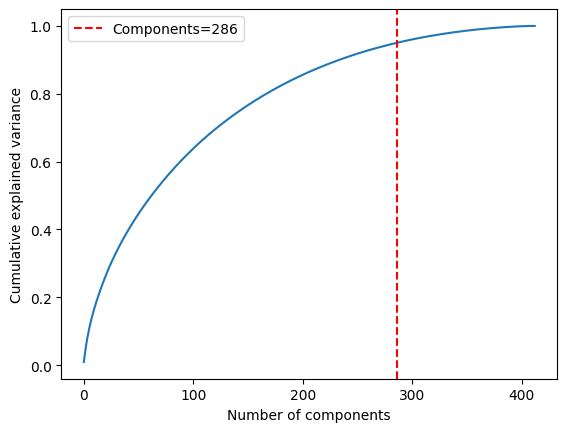

In [41]:
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt
import numpy as np

X = tfidf_matrix

svd = TruncatedSVD(n_components=X.shape[1]-1)
svd.fit(X)

cumulative_explained_variance = np.cumsum(svd.explained_variance_ratio_)

n_components = np.where(cumulative_explained_variance > 0.95)[0][0]

print(f"Number of components for 95% variance: {n_components}")

plt.plot(cumulative_explained_variance)
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.axvline(x=n_components, color='r', linestyle='--', label=f'Components={n_components}')
plt.legend()
plt.show()

### Spectral Clustering

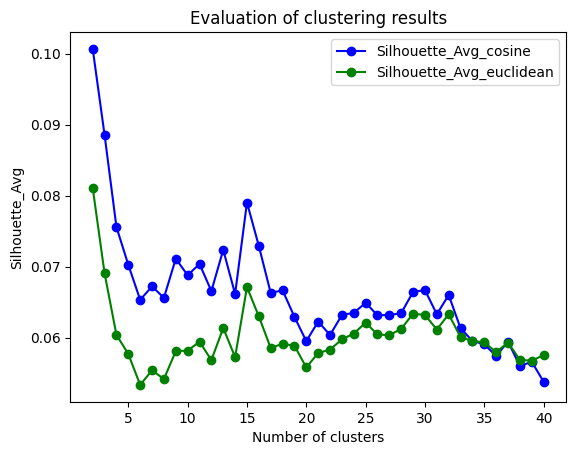

In [42]:
# find optimal cluster numbers
vectorizer = TfidfVectorizer(vocabulary=select_keywords_list)
tfidf_matrix = vectorizer.fit_transform(df['corpus'])

# svd = TruncatedSVD(n_components=n_components)
# reduced_data = svd.fit_transform(tfidf_matrix)
reduced_data = tfidf_matrix

metrics = ['cosine', 'euclidean']

cluster_range = range(2, 41)

results = {}

for metric in metrics:
    results[metric] = []

    for n_clusters in cluster_range:
        silhouette_avg_list = []

        # 유사도/거리 행렬 생성
        if metric == 'cosine':
            similarity_matrix = cosine_similarity(reduced_data)
        elif metric == 'euclidean':
            similarity_matrix = euclidean_distances(reduced_data)

        # Spectral Clustering 실행 (10번 반복)
        for _ in range(10):
            sc = SpectralClustering(n_clusters=n_clusters, random_state=0).fit(reduced_data)
            labels=sc.labels_

            silhouette_avg_list.append(silhouette_score(similarity_matrix, labels))

        results[metric].append(np.mean(silhouette_avg_list))

for metric in metrics:

    if metric == 'cosine':
        color = 'b'
    elif metric == 'euclidean':
        color = 'g'

    plt.plot(cluster_range, results[metric], label=f'Silhouette_Avg_{metric}', marker='o', color = color)

plt.title('Evaluation of clustering results')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette_Avg')
plt.legend()
plt.show()

## Interpreting the clusters

### Simple analysis

In [43]:
from sklearn.feature_selection import chi2, f_classif

vectorizer = TfidfVectorizer(vocabulary=select_keywords_list)
X = vectorizer.fit_transform(df['corpus'])

n_clusters = 20
clustering = SpectralClustering(n_clusters=n_clusters, assign_labels="discretize", random_state=0).fit(X)
labels = clustering.labels_

keywords = []
for i in range(n_clusters):
    cluster_data = X[labels == i]
    cluster_labels = np.zeros_like(labels)
    cluster_labels[labels == i] = 1

    chi2score = chi2(X, cluster_labels)[0]
    fvalues, _ = f_classif(X, cluster_labels)

    topchi2 = np.argsort(chi2score)[::-1][:10]
    topfvalues = np.argsort(fvalues)[::-1][:10]


    keywords.append([vectorizer.get_feature_names_out()[index] for index in topchi2[:10]])
    keywords.append([vectorizer.get_feature_names_out()[index] for index in topfvalues[:10]])

for i in range(n_clusters):
    print("Cluster %d:" % i, "contains %d documents" % sum(labels == i))
    print("Chi-squared keywords:", keywords[i*2])
    print("F values keywords:", keywords[i*2+1])

Cluster 0: contains 56 documents
Chi-squared keywords: ['care', 'nursing', 'health', 'community', 'rehabilitation', 'patient', 'chronic', 'elderly', 'medical', 'hospital']
F values keywords: ['care', 'health', 'nursing', 'community', 'patient', 'chronic', 'hospital', 'medical', 'elderly', 'rehabilitation']
Cluster 1: contains 42 documents
Chi-squared keywords: ['privacy', 'data', 'preserving', 'upload', 'personal', 'anonymity', 'log', 'user', 'social', '6lowpan']
F values keywords: ['data', 'privacy', 'preserving', 'upload', 'personal', 'user', 'anonymity', 'log', 'information', 'social']
Cluster 2: contains 42 documents
Chi-squared keywords: ['web', 'object', 'thing', 'semantic', 'bacnet', 'medication', 'composition', 'et', 'music', 'virtual']
F values keywords: ['web', 'object', 'thing', 'semantic', 'application', 'internet', 'music', 'bacnet', 'composition', 'domain']
Cluster 3: contains 49 documents
Chi-squared keywords: ['framework', 'smart', 'home', 'heterogeneous', 'environment'

### Topic modeling(NMF & LDA)

In [44]:
from sklearn.decomposition import NMF, LatentDirichletAllocation
n_topics = 1

In [45]:
nmf = NMF(n_components=n_topics, random_state=1)
nmf_topics = []

for i in range(n_clusters):
    cluster_data = X[labels == i]

    nmf.fit(cluster_data)
    nmf_topic_words = nmf.components_.argsort()[:, ::-1]
    nmf_topics.append(nmf_topic_words)

In [46]:
lda = LatentDirichletAllocation(n_components=n_topics, random_state=1)
lda_topics = []

for i in range(n_clusters):
    cluster_data = X[labels == i]

    lda.fit(cluster_data)
    lda_topic_words = lda.components_.argsort()[:, ::-1]
    lda_topics.append(lda_topic_words)

In [47]:
n_top_words = 10  # 상위 키워드 수를 설정합니다. 원하는 수로 변경 가능합니다.

for i in range(n_clusters):
    print("Cluster %d:" % i)

    for j in range(n_topics):
        print("NMF Topic %d:" % j, [vectorizer.get_feature_names_out()[index] for index in nmf_topics[i][j, :n_top_words]])
        print("LDA Topic %d:" % j, [vectorizer.get_feature_names_out()[index] for index in lda_topics[i][j, :n_top_words]])


Cluster 0:
NMF Topic 0: ['care', 'health', 'service', 'home', 'elderly', 'community', 'smart', 'system', 'nursing', 'patient']
LDA Topic 0: ['care', 'health', 'service', 'home', 'community', 'elderly', 'nursing', 'smart', 'system', 'patient']
Cluster 1:
NMF Topic 0: ['data', 'privacy', 'smart', 'home', 'user', 'service', 'system', 'information', 'personal', 'approach']
LDA Topic 0: ['data', 'privacy', 'home', 'smart', 'user', 'service', 'system', 'information', 'approach', 'personal']
Cluster 2:
NMF Topic 0: ['web', 'object', 'thing', 'service', 'iot', 'home', 'smart', 'application', 'device', 'internet']
LDA Topic 0: ['web', 'object', 'service', 'thing', 'home', 'smart', 'application', 'iot', 'device', 'internet']
Cluster 3:
NMF Topic 0: ['home', 'smart', 'framework', 'service', 'device', 'environment', 'system', 'technology', 'appliance', 'user']
LDA Topic 0: ['home', 'smart', 'framework', 'service', 'device', 'environment', 'system', 'technology', 'user', 'appliance']
Cluster 4:
NMF

In [48]:
vectorizer = TfidfVectorizer(vocabulary=select_keywords_list)
X = vectorizer.fit_transform(df['corpus'])

n_clusters = 20
clustering = SpectralClustering(n_clusters=n_clusters, assign_labels="discretize", random_state=0).fit(X)
clusters = clustering.labels_

cos_sim = cosine_similarity(X)
mean_sim = np.mean(cos_sim)

binary_adj_matrix = np.where(cos_sim > mean_sim, 1, 0)

### Visualization  - Longabaugh

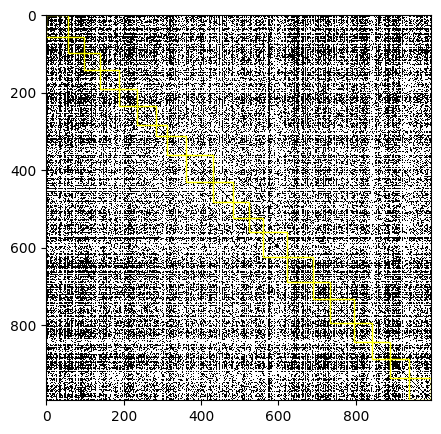

In [49]:
import networkx as nx
from matplotlib import pyplot, patches

def draw_adjacency_matrix(G, node_order=None, partitions=[], colors=[]):
    """
    - G is a netorkx graph
    - node_order (optional) is a list of nodes, where each node in G
          appears exactly once
    - partitions is a list of node lists, where each node in G appears
          in exactly one node list
    - colors is a list of strings indicating what color each
          partition should be
    If partitions is specified, the same number of colors needs to be
    specified.
    """
    adjacency_matrix = nx.to_numpy_array(G, dtype=np.bool, nodelist=node_order)

    #Plot adjacency matrix in toned-down black and white
    fig = pyplot.figure(figsize=(5, 5)) # in inches
    pyplot.imshow(adjacency_matrix,
                  cmap="Greys",
                  interpolation="none")

    # The rest is just if you have sorted nodes by a partition and want to
    # highlight the module boundaries
    assert len(partitions) == len(colors)
    ax = pyplot.gca()
    current_idx = 0
    for partition, color in zip(partitions, colors):
        ax.add_patch(patches.Rectangle((current_idx, current_idx),
                                          len(partition), # Width
                                          len(partition), # Height
                                          facecolor="none",
                                          edgecolor=color,
                                          linewidth=1))
        current_idx += len(partition)

G = nx.from_numpy_array(binary_adj_matrix)

partitions = []
for i in range(20):
    partitions.append([idx for idx, cluster in enumerate(clusters) if cluster == i])

colors = ['#FFFF00' for _ in range(20)]
draw_adjacency_matrix(G, partitions=partitions, colors=colors)

### Network analysis

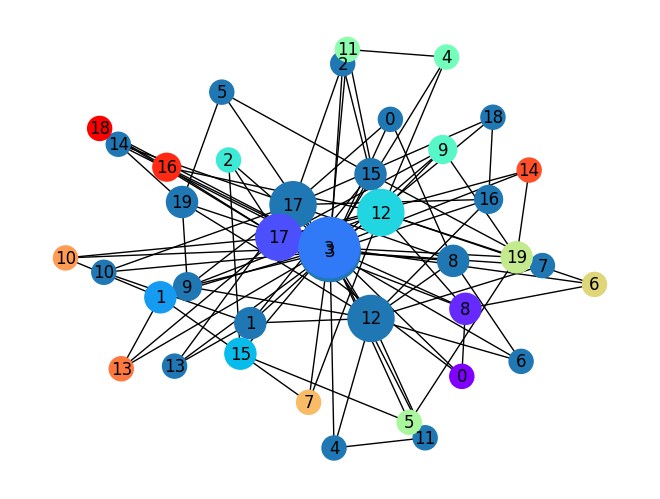

In [50]:
from operator import itemgetter
import matplotlib.cm as cm

clustering = SpectralClustering(n_clusters=n_clusters, assign_labels="discretize", random_state=0).fit(X)

# 각 클러스터의 중심점 계산
centroids = []
for i in range(n_clusters):
    members = X[clustering.labels_ == i]
    centroid = members.mean(axis=0).A
    if centroid.shape[0] == 1:
        centroid = centroid[0]
    centroids.append(centroid)

similarity_matrix = cosine_similarity(centroids)

# 각 클러스터에서 가장 유사한 3개의 클러스터를 찾기
top_clusters = {}
for i in range(n_clusters):
    similar_clusters = sorted(list(enumerate(similarity_matrix[i])), key=itemgetter(1), reverse=True)[1:4]
    top_clusters[i] = [idx for idx, similarity in similar_clusters]

G = nx.Graph()
for cluster, neighbors in top_clusters.items():
    for neighbor in neighbors:
        G.add_edge(cluster, neighbor)

sizes = [G.degree(node) * 100 for node in G]
nx.draw(G, with_labels=True, node_size=sizes)

colors = cm.rainbow(np.linspace(0, 1, n_clusters))
node_colors = [colors[i] for i in range(n_clusters)]

nx.draw(G, with_labels=True, node_size=sizes, node_color=node_colors)

##  STEP 4 : Exploratory factor analysis